### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [203]:
#Reading the coupons.csv file in a folder named data
data = pd.read_csv('data/coupons.csv')

In [204]:
# see the first 5 rows of the dataset "data"
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [205]:
# finding the number of rows and columns in dataset "data"
data.shape

(12684, 26)

In [206]:
# finding the null values (no entries) in the dataset "data"
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [207]:
## finding the Not Available (NA entries) in the dataset "data"
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [208]:
#Since both missing and problematic data reveals the same information
data.isna().sum() == data.isnull().sum()

destination             True
passanger               True
weather                 True
temperature             True
time                    True
coupon                  True
expiration              True
gender                  True
age                     True
maritalStatus           True
has_children            True
education               True
occupation              True
income                  True
car                     True
Bar                     True
CoffeeHouse             True
CarryAway               True
RestaurantLessThan20    True
Restaurant20To50        True
toCoupon_GEQ5min        True
toCoupon_GEQ15min       True
toCoupon_GEQ25min       True
direction_same          True
direction_opp           True
Y                       True
dtype: bool

In [209]:
#Finding the % of missing and problematic data as both are same
# if the missing data is > 2% removing that column i.e. car in this case
#finding the percentage of missing and problematic data
(data.isnull().sum()/len(data))*100

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

3. Decide what to do about your missing data -- drop, replace, other...

In [210]:
#setting threshold to be 2 % 
threshold = 0.02
# creating a new dataset "data1" with this threshold i.e. removing "car"column
data1 = data.loc[:, data.isnull().mean() <= threshold]
#checking the info about the dataset "data1"
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

In [211]:
#creating cols variable indicating the columns to be cleaned
cols = ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']

#creating an explicit copy of "data1" before modifying it
data1 = data1.copy()

# replacing the five columns with non-zero % of problematic data replacing empyr or whitespace only cells with NaN
data1[cols] = data1[cols].replace(r'^\s*$', np.nan, regex=True)

# removing any row where any of these 5 columns listed in "cols" contains NaN
data1 = data1.dropna(subset=cols)

#checking info of "data1"
data1.info ()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passanger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   time                  12079 non-null  object
 5   coupon                12079 non-null  object
 6   expiration            12079 non-null  object
 7   gender                12079 non-null  object
 8   age                   12079 non-null  object
 9   maritalStatus         12079 non-null  object
 10  has_children          12079 non-null  int64 
 11  education             12079 non-null  object
 12  occupation            12079 non-null  object
 13  income                12079 non-null  object
 14  Bar                   12079 non-null  object
 15  CoffeeHouse           12079 non-null  ob

In [212]:
# doublechecking any missing or problematic values in dataset "data1"
data1.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?

In [217]:
#checking the Y column with value 1 
(data1["Y"]==1).mean()

np.float64(0.5693352098683666)

In [216]:
# finding the proportion
data1["Y"].value_counts(normalize=True)

Y
1    0.569335
0    0.430665
Name: proportion, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

In [218]:
#Checking the first 5 rows of data1 to identify the variables for plot
data1.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
25,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


<Axes: title={'center': 'Distribution of Coupons'}, xlabel='coupon'>

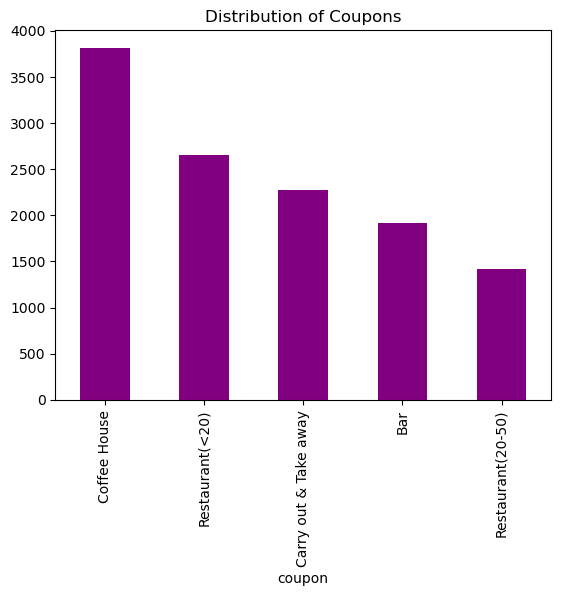

In [219]:
#bar plot for coupons using "plot" function
data1['coupon'].value_counts().plot(kind='bar', color= 'purple', title = 'Distribution of Coupons')

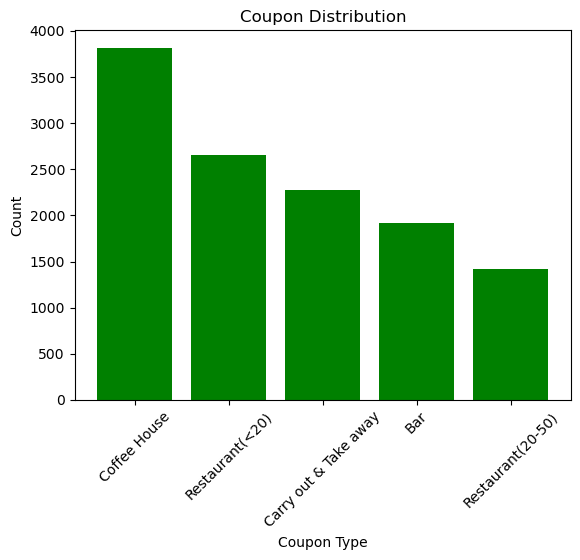

In [220]:
# using matplotlib
import matplotlib.pyplot as plt
counts = data1['coupon'].value_counts()
plt.bar(counts.index, counts.values, color = 'green')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Coupon Distribution')
plt.xticks(rotation = 45) # rotation in the bar labels by 45 degree
plt.show()


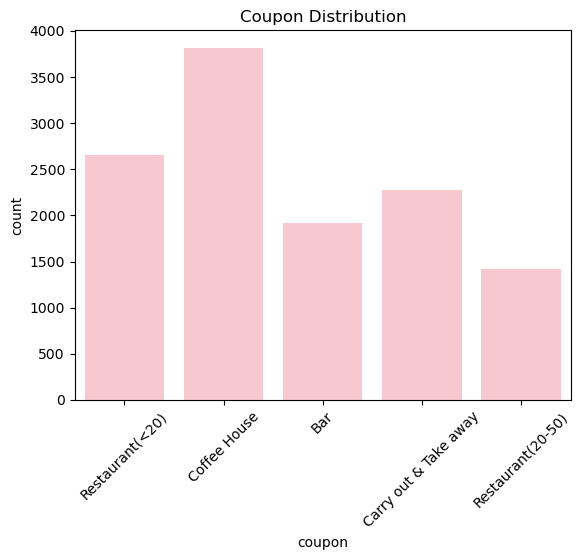

In [221]:
# barplot of coupon using seaborn library 
sns.countplot(x='coupon', data = data1, color = 'pink')
plt.xticks(rotation = 45) # rotation in the bar labels by 45 degree
plt.title('Coupon Distribution')
plt.show()

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Histogram of temperature')

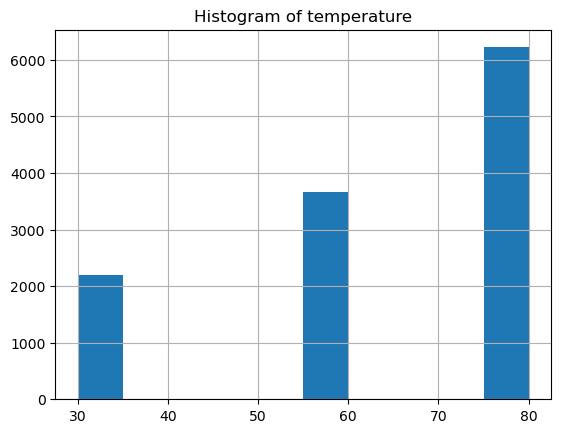

In [222]:
#using hist function
data1['temperature'].hist()
plt.title('Histogram of temperature')

Text(0.5, 1.0, 'Histogram of temperature')

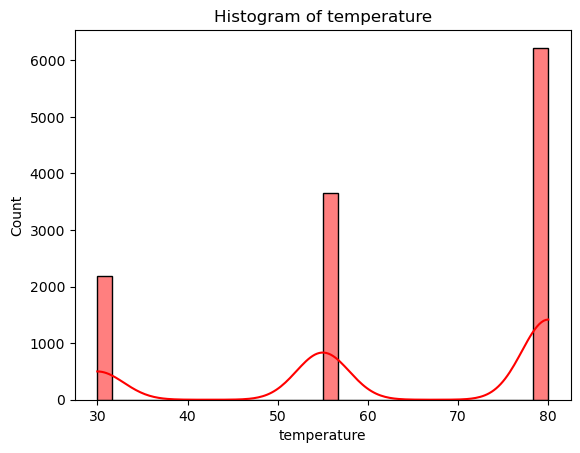

In [223]:
#using seborn library barplot of temperature
sns.histplot(data1['temperature'], bins=30,kde=True, color = 'red')
plt.title('Histogram of temperature')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [224]:
#creating a dataframe "data1_bar" only for column coupon = bar
data1_bar = data1[data1['coupon'] == 'Bar']
data1_bar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1913 entries, 24 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1913 non-null   object
 1   passanger             1913 non-null   object
 2   weather               1913 non-null   object
 3   temperature           1913 non-null   int64 
 4   time                  1913 non-null   object
 5   coupon                1913 non-null   object
 6   expiration            1913 non-null   object
 7   gender                1913 non-null   object
 8   age                   1913 non-null   object
 9   maritalStatus         1913 non-null   object
 10  has_children          1913 non-null   int64 
 11  education             1913 non-null   object
 12  occupation            1913 non-null   object
 13  income                1913 non-null   object
 14  Bar                   1913 non-null   object
 15  CoffeeHouse           1913 non-null   obj

In [225]:
data1_bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [226]:
(data1_bar["Y"]==1).mean() # checking the Y column with 1 in this dataset 

np.float64(0.41191845269210664)

In [227]:
len(data1_bar)

1913

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [228]:
data1_bar.duplicated().sum() # finding the number of duplicated entries

np.int64(7)

In [229]:
data1_bar['Bar'].unique() #finding the unique entries or different possible values in "Bar"

array(['never', 'less1', '1~3', 'gt8', '4~8'], dtype=object)

In [230]:
data1_bar[data1_bar.duplicated()] #checking for the duplicated entries

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
7843,No Urgent Place,Friend(s),Rainy,55,10PM,Bar,2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,1,0,0,1,0
7847,No Urgent Place,Partner,Sunny,30,10AM,Bar,1d,Female,31,Married partner,...,less1,gt8,4~8,less1,1,1,0,0,1,1
7855,Home,Alone,Sunny,80,6PM,Bar,2h,Female,31,Married partner,...,less1,gt8,4~8,less1,1,0,0,1,0,0
8496,No Urgent Place,Kid(s),Rainy,55,10PM,Bar,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
8497,No Urgent Place,Kid(s),Snowy,30,6PM,Bar,1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,0
8503,No Urgent Place,Friend(s),Rainy,55,10PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,1
8511,Home,Alone,Sunny,80,6PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1


In [231]:
data1_bar = data1_bar.drop_duplicates() #removing the 7 duplicate entries
len(data1_bar) # checking the length of data set after removing the duplicates

1906

In [232]:
R1 = (((data1_bar['Bar'] == '1~3') | (data1_bar['Bar'] == 'less1')) & (data1_bar['Y'] == 1)).sum()
R1 # those who went less than 3 times to bar and accepted coupon

np.int64(489)

In [237]:
R2 = (((data1_bar['Bar'] == '4~8') | (data1_bar['Bar'] == 'gt8')) & (data1_bar['Y'] == 1)).sum()
R2 # who went more than 3 times and accepted coupon

np.int64(147)

In [238]:
R3 = ((data1_bar['Bar'] == 'never') & (data1_bar['Y'] == 1)) .sum()
R3 # those who never went to bar but accepted coupon

np.int64(149)

In [239]:
R4 = (data1_bar['Y'] == 0) .sum()
R4 # who never accepted the Bar coupons

np.int64(1121)

In [240]:
R5 = (data1_bar['Y'] == 1) .sum()
R5 # total accepted coupons for "Bar"

np.int64(785)

In [241]:
Accept_3Bar = (R1/R5)*100
Accept_3Bar

np.float64(62.29299363057324)

In [242]:
Accept_More = (R2/R5)*100
Accept_More

np.float64(18.726114649681527)

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [243]:
R3 = ((data1_bar['Bar'] != 'never') & (data1_bar['age'] > '25') & (data1_bar['Y'] == 1)).sum()
R3 

np.int64(465)

In [244]:
R4 = ((data1_bar['age'] > '25') & (data1_bar['Y'] == 1)).sum()
R4 

np.int64(585)

In [245]:
Accept_R_age= (R3/R5)*100
Accept_R_age # The acceptance rate for the driver over the age of 25 is > drivers who go to a bar more than once a month

np.float64(59.23566878980891)

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [246]:
R6 = ((data1_bar['Bar'] != 'never') & (~data1_bar['occupation'].isin(['fishing', 'farming', 'forestry'])) & (data1_bar['passanger'] != 'kid(s)') & (data1_bar['Y'] == 1)) .sum()
R6 # Bar visits are not ‘never’, occupation is not fishing, farming, or forestry, the passenger is not ‘kid(s)’, and the coupon was accepted (Y = 1). 
# ~ means the negation of the condition and it reverses the result

np.int64(636)

In [247]:
Accept_R_nokids = (R6/R5)*100
Accept_R_nokids

np.float64(81.01910828025478)

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [249]:
R7 = ((data1_bar['Bar'] != 'never') & (~data1_bar['passanger'].isin(['kid(s)','widowed'])) & (data1_bar['Y'] == 1)) .sum()
R7 # drivers more than a month visit and no: of passengers that were not a kid, and were not widowed

np.int64(636)

In [250]:
R8 = ((data1_bar['Bar'] != 'never') & (data1_bar['age'] < '30') & (data1_bar['Y'] == 1)).sum()
R8 #drivers more than a month visit and are under the age of 30

np.int64(328)

In [251]:
R9 = ((data1['coupon'] == 'Restaurant(<20)') & (data1['income'] < '50000') & (data1['RestaurantLessThan20'].isin(['gt8','4~8'])) & (data1['Y'] == 1)).sum()
R9 # drivers going to cheap restaurants more than 4 times a month and income is less than 50K

np.int64(696)

In [252]:
R10 = (data1['Y'] == 1) .sum()
R10

np.int64(6877)

In [253]:
Accept_R_NK_W = (R7/R5) *100
Accept_R_NK_W #acceptance rate for R7

np.float64(81.01910828025478)

In [254]:
Accept_R_30 = (R8/R5)*100
Accept_R_30 #acceptance rate for R8

np.float64(41.783439490445865)

In [255]:
Accept_R_Cheap = (R9/R10)*100
Accept_R_Cheap #acceptance rate for R9

np.float64(10.120692162280063)

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
# My abstracted and refined hypothesis says:
#1.	Moderate users (not frequent bar-goers) are more likely to accept coupons.
#2.	Environmental conditions (temperature) influence behavior.
#3.	Demographics (age, passengers, occupation) significantly impact decisions.
#4.	High-value coupons (expensive restaurants) are less attractive.
#5. Lifestyle factors outperform income-based factors in predicting acceptance.
#6.	Behavioral segmentation provides better insights than single-variable analysis.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  